# Quantum Error Correction

## Two-qubit error correction

In this tutorial, we present a simple, fully controlled example of Quantum Error Correction (QEC) concepts using a two-qubit system.

### 1. System Initialization
We begin by defining our system.
* **Qubit 1** is the data qubit, prepared in an arbitrary superposition state:
    $$
    |\psi\rangle = \alpha |0\rangle + \beta|1\rangle
    $$
* **Qubit 2** is the ancilla (auxiliary) qubit, initialized in the ground state:
    $$
    |0\rangle
    $$

Before any operations or errors occur, the joint state of the system is the tensor product of the two qubits:
$$
    |\Psi\rangle_{\text{initial}} = (\alpha |0\rangle + \beta|1\rangle) \otimes |0\rangle = \alpha |00\rangle + \beta|10\rangle
$$

### 2. The Error Model
We assume a simple noise model consisting of bit-flip errors (Pauli-X gates). The errors acting on the first or second qubit are represented as:
$$
    X_1 = X \otimes I, \quad X_2 = I \otimes X
$$
These operators have the effect of flipping the state ($|0\rangle \leftrightarrow |1\rangle$) of the specific qubit they act upon.

### 3. What are we trying to protect?
Currently, our logical information is stored entirely in Qubit 1. If a bit-flip error ($X_1$) occurs on the first qubit, the logical state is corrupted:
$$
    X_1 |\Psi\rangle_{\text{initial}} = \alpha |10\rangle + \beta|00\rangle
$$
Because the second qubit is always $|0\rangle$, any change to the first qubit immediately destroys the information. To mitigate this, we need **redundancy**.

> **Note:** With only two qubits, we cannot correct arbitrary single-qubit bit-flips in a full fault-tolerant sense (we cannot distinguish *which* qubit flipped), but we can use this system to clearly illustrate the **encoding** and **stabilizer** mechanisms.

### 4. Encoding the Logical Qubit
To detect bit-flips, we encode the state into a **two-qubit repetition code**:
$$
    |\psi\rangle_L = \alpha |00\rangle + \beta|11\rangle
$$
To obtain this entangled state, we perform a CNOT gate with Qubit 1 as the control and Qubit 2 as the target.

Mathematically, the CNOT operation transforms the initial joint state:
$$
    \text{CNOT} \big( (\alpha |0\rangle + \beta|1\rangle) \otimes |0\rangle \big) \longrightarrow \alpha |00\rangle + \beta|11\rangle
$$
Notice that the information ($\alpha$ and $\beta$) is now distributed across both qubits (entanglement). The system is now in a correlated state where both qubits should always have the same value ($00$ or $11$).

### 1. Step: Import libraries

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Clifford, StabilizerState

### 2. Step: Define initial state \& state vector

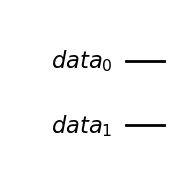

In [4]:
# Define data with QuantumRegister
data = QuantumRegister(2, 'data')

# Create the circuit from data
qc = QuantumCircuit(data)

# Draw initial circuit
qc.draw('mpl')

In [3]:
sv_initial = Statevector(qc)
sv_initial.draw('latex')

<IPython.core.display.Latex object>

### 3. Step: Generate Bell state \& statevector

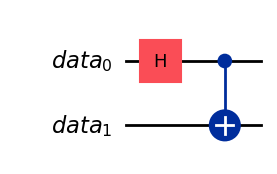

In [ ]:
# Add H and CX gates
qc.h(0)
qc.cx(0,1)

# Draw the circuit
qc.draw('mpl')

In [4]:
sv_initial = Statevector(qc)
sv_initial.draw('latex')

<IPython.core.display.Latex object>

### 4. Step: Gather stabilizer generators; stabilizers \& destabilizers

In [6]:
# Base circuit is Clifford; it only contains operators in Clifford group

# Stabilizers by StabilizerState
stab_after = StabilizerState(qc)

print(f"Stabilizer generators: {stab_after.clifford.to_labels()}")

# Stabilizers and Destabilizers by Clifford class
# Convert the circuit to a Clifford operator (Tableau representation)
after_cliff = Clifford(qc)
print(after_cliff)

Stabilizer generators: ['+IZ', '+XI', '+XX', '+ZZ']
Clifford: Stabilizer = ['+XX', '+ZZ'], Destabilizer = ['+IZ', '+XI']


## Process to follow for error correction: step by step mathematical description
For the two-qubit bit-flip code, the stabilizer generator is:
$$
    S = Z_1 Z_2
$$
which can be checked through the encoded state is stabilized:
$$
    Z_1 Z_2 \ket{00} = + \ket{00}, \quad Z_1 Z_2 \ket{11} = + \ket{11}
$$
accordingly:
$$
    Z_1 Z_2 \ket{\psi}_L = + \ket{\psi}_L
$$
Thus the codespace is the $+1$ eigenspace of $Z_1 Z_2$ and this is the key stabilizer idea:

> **The logical state lives in the $+1$ eigenspace of the stabilizer.**

### A - Effect of errors on the stabilizer
Now lets us see how bit-flip errors affect the stabilizer measurement.

**Case 1 - No error**
$$
    Z_1 Z_2 (I_1 I_2) \ket{\psi}_L = +\ket{\psi}_L
$$
Syndrome $=+1$.

---

**Case 2 - Error $X_1 I_2$**
$$
    X_1 I_2 (\ket{\psi}_L)= X_1 I_2 (\alpha \ket{00} + \beta \ket{11}) = \alpha \ket{10} + \beta \ket{01}
$$
Now apply the stabilizer:
$$
    Z_1 Z_2 \ket{10} = (-1)(+1)\ket{10} = - \ket{10} \\
    Z_1 Z_2 \ket{01} = (+1)(-1)\ket{01} = - \ket{01}
$$
So,
$$
    Z_1 Z_2 (X_1 I_2 \ket{\psi}_L) = - X_1 I_2 \ket{\psi}_L
$$
Syndrome $=-1$.

---

**Case 3 - Error $I_1 X_2$**
$$
    I_1 X_2 (\ket{\psi}_L)= I_1 X_2 (\alpha \ket{00} + \beta \ket{11}) = \alpha \ket{01} + \beta \ket{10}
$$
Now apply the stabilizer:
$$
    Z_1 Z_2 \ket{01} = (-1)(+1)\ket{01} = - \ket{01} \\
    Z_1 Z_2 \ket{10} = (+1)(-1)\ket{10} = - \ket{10}
$$
So,
$$
    Z_1 Z_2 (I_1 X_2 \ket{\psi}_L) = - I_1 X_2 \ket{\psi}_L
$$
Syndrome $=-1$.

---

**Case 4 - Error $X_1 X_2$**
$$
    X_1 X_2 (\ket{\psi}_L) = X_1 X_2 (\alpha \ket{00} + \beta \ket{11}) = (\alpha \ket{11} + \beta \ket{00})
$$
Apply the stabilizer:
$$
    Z_1 Z_2 (\alpha \ket{11}) = (-1)(-1)\ket{11} =  + \alpha \ket{11} \\
    Z_1 Z_2 (\beta \ket{00}) = (+1)(+1)\ket{00} = + \beta \ket{00}
$$
So:
$$
    Z_1 Z_2 (X_1 X_2 \ket{\psi}_L) = + \ket{\psi}_L
$$
Syndrome $+1$.

The two-qubit code detects a bit-flip, but it cannot distinguish whether it was on qubit-1 or qubit-2. Both errors give the same syndrome. This is crucial:
* Stabilizers detect errors through commutation relations.
* If an error anticommutes with a stabilizer, the syndrome flips.
* To correct errors, you need enough stabilizers to uniquely identify them.

That is why the full bit-flip code uses three qubits.

### B - Syndrome extraction circuit:
To measure $Z_1 Z_2$, introduce an ancilla qubit:

#### 1. Step: Prepare ancilla in $\ket{0}$.

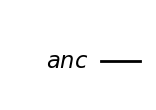

In [6]:
anc = QuantumRegister(1, 'anc')
qc2 = QuantumCircuit(anc)
qc2.draw(output='mpl')

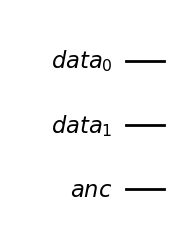

In [7]:
qc = QuantumCircuit(data, anc)
qc.draw(output='mpl')

### 2. Step:  Apply $CNOT$ from qubit-0 to ancilla \& from qubit_1 to ancilla.

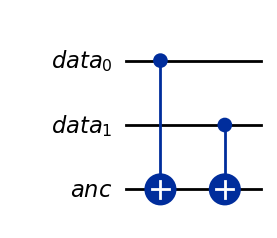

In [8]:
qc.cx(data,anc)
qc.draw('mpl')

### 3. Step: Measurement ancilla, result:
* 0 → eigenvalue +1 → no error
* 1 → eigenvalue -1 → error occurred

This is stabilizer syndrome extraction.

### Stabilizer language summary
We can summarise the stabilizer formalism for this example:

Codespace:
$$
    \mathcal{C} = \{\ket{\psi} | Z_1 Z_2 \ket{\psi} = + \ket{\psi}\}
$$
Logical operations:
$$
    \bar{X} = X_1 X_2 \\
    \bar{Z} = Z_1 = Z_2
$$
Error detection rule:

**An error $E$ is detectable if it anticommutes with at least one stabilizer generator.**

Since:
$$
    \{ X_1, Z_1 Z_2 \} = 0, \quad \{ X_2, Z_1 Z_2 \} = 0
$$
bit-flips are detectable.

## Three-qubit error correction:
The three-qubit repetition code is the first fully working example where stabilisers not only detect but also identify a single bit-flip.

We build it cleanly in stabiliser language.

### 1. Logical encoding
Start with one qubit:
$$
    \ket{\psi} = \alpha \ket{0} + \beta \ket{1}
$$
Encode using two CNOTs:
$$
    \ket{\psi} \ket{00} \xrightarrow{\text{CNOT}_{1 \rightarrow 2}, \text{CNOT}_{1 \rightarrow 3}} \alpha \ket{000} + \beta \ket{000}
$$
So the logical state is:
$$
    \ket{\psi}_L = \alpha \ket{000} + \beta \ket{000}.
$$
Information is now redundantly stored across three qubits.

### 2. Stabiliser generators
The three-qubit bit-flip code has two stabiliser generators:
$$
    S_1 = Z_1 Z_2 \\
    S_2 = Z_2 Z_3
$$
The codespace is defined by
$$
    S_1 \ket{\psi}_L = + \ket{\psi}_L \\
    S_2 \ket{\psi}_L = + \ket{\psi}_L
$$
Check this quickly:
* $Z_1 Z_2 \ket{000} = + \ket{000}$
* $Z_1 Z_2 \ket{111} = + \ket{111}$

Same for $Z_2 Z_3$. So the encoded state lives in the $+1$ eigenspace of both stabilisers.

This gives us a $2$-dimensional codespace inside the 8-dimensional Hilbert space.

### 3. Logical operators
Logical operation must:
1. Commute with stabilizers
2. Not belong to the stabilizer group

They are:
$$
    \bar{X} = X_1 X_2 X_3 \\
    \bar{Z} = Z_1 = Z_2 = Z_3
$$
Why?
* $X_1 X_2 X_3$ flips $\ket{000} \leftrightarrow \ket{111}$
* A single $Z_i$ acts correctly as logical phase within the codespace $\mathcal{C}$

### 5. Syndrome table
We commute eigenvalues of $S_1$ and $S_2$.

**Case 1: No error**
$$
    (+1,+1)
$$

---

**Case 2: Error X_1**

State becomes:
$$
    \alpha \ket{100} + \beta \ket{011}
$$
Check stabilizers:
* $Z_1 Z_2 \rightarrow$ anticommutes with $X_1 \rightarrow$ eigenvalue $-1$
* $Z_2 Z_3 \rightarrow$ commutes with $X_1 \rightarrow$ eigenvalue $+1$

Syndrome:
$$
    (-1,+1)
$$

---

**Case 3: Error X_2**

Anticommutes with both stabilizers.

Syndrome:
$$
    (-1,-1)
$$

---

**Case 4: Error X_3**

Anticommutes with both stabilizers.

Syndrome:
$$
    (+1,-1)
$$

### 6. Full syndrome table

\begin{array}{c|c|c}
\text{Error} & S_1 = Z_1 Z_2 & S_2 = Z_2 Z_3 \\
\hline
I     & +1 & +1 \\
X_1   & -1 & +1 \\
X_2   & -1 & -1 \\
X_3   & +1 & -1 \\
\end{array}

Now we can uniquely identify the error location.

This is the crucial difference from the two-qubit case.

### 7. Syndrome extraction circuit

We measure each stabiliser using an ancilla.

For $Z_1 Z_2$:

data1 ──■────
        │

data2 ──■────
        │

anc1  ──X─M

For $Z_2 Z_3$:

data2 ──■────
        │

data3 ──■────
        │
        
anc2  ──X─M

### 8. Recovery rule

After measuring:
* $(-1,+1) \rightarrow$ apply $X_1$
* $(-1,-1) \rightarrow$ apply $X_2$
* $(+1,-1) \rightarrow$ apply $X_3$
* $(+1,+1) \rightarrow$ do nothing

That restores the state to:
$$
    \alpha \ket{000} + \beta \ket{111}
$$

### 9. Why this works - stabiliser viewpoint

The mechanism is purely algebraic:

* Errors are Pauli operators.

* Pauli operators either commute or anticommute.

* Anticommutation flips stabiliser eigenvalues.

* The pattern of sign flips forms a binary syndrome.

Error correction becomes linear algebra over $\mathbb{F}_2$.

That is the conceptual jump from circuits to stabilizer codes.

### 10. Important limitation

This code:

Corrects one bit-flip

Cannot correct phase flips

Cannot correct two simultaneous bit-flips

To handle both $X$ and $Z$ errors, we need CSS codes - which leads naturally to Shor's $9-$qubit code or the Steane code.